# 06 — Improvement direction: a curated mean-reversion universe

nb05 showed the edge is mean-reversion and grades with each asset's *character*. nb03 showed the champion's binding limit is **only 2 names / ~8% time-in-position** (the harness composite penalizes time-in-position < 20%). Idea: **select a basket of the most mean-reverting coins and trade them alongside BTC/ETH** — more activity + diversification without the dilution that sank the old unfiltered broad-universe attempts (harness iters 3/8/12).

**The lookahead rule (non-negotiable).** Selection must be **causal**: at each month-start we rank coins by their **trailing** 60-day lag-1 autocorrelation (computed only on data before that month) and trade the selected set the following month. We never select on full-period character — that would be the anchor-selection lookahead that turned the pump line's +77% into a loss.

**Prediction.** (1) The causal MR-filter has real signal → MR-selected basket beats the full unfiltered universe and a most-*trending* control. (2) But in the 2024–26 alt bear even the best alt basket won't beat BTC/ETH standalone. (3) The payoff is the **combo**: BTC/ETH + an MR-alt sleeve lifts activity (clears the composite's time-in-position penalty) and diversifies drawdown at little Sharpe cost.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from pathlib import Path
START, END = "2024-01-01", "2026-01-01"
syms = list(pd.read_parquet("_out/03_universe_full.parquet").symbol)

# Per-symbol strategy NET-return series + coin returns (cached: heavy to recompute).
NC, CC = Path("_out/06_net_matrix.parquet"), Path("_out/06_coinret_matrix.parquet")
if NC.exists():
    net = pd.read_parquet(NC); coinret = pd.read_parquet(CC)
else:
    nets, crs = {}, {}
    for s in syms:
        try: df = ohlcv(s, START, END, "1h")
        except Exception: continue
        if len(df) < 500: continue
        nets[s] = backtest(strat_signals(df, s), df["close"])["net"]
        crs[s] = df["close"].pct_change()
    net = pd.DataFrame(nets); coinret = pd.DataFrame(crs)
    net.to_parquet(NC); coinret.to_parquet(CC)
print("net matrix:", net.shape, "| symbols:", net.shape[1])

net matrix: (17544, 148) | symbols: 148


In [2]:
# ---- causal monthly selection machinery ----
L = pd.Timedelta(days=60)                       # trailing window for the character estimate
months = pd.date_range("2024-03-01", "2025-12-01", freq="MS", tz="UTC")  # after 60d warmup

def trailing_ac(m):
    """lag-1 autocorr of each coin's returns over [m-60d, m) — data known at m."""
    w = coinret.loc[(coinret.index >= m - L) & (coinret.index < m)]
    return w.apply(lambda c: c.dropna().autocorr(1) if c.dropna().shape[0] > 200 else np.nan)

def selected_portfolio(selector, K):
    """Equal-weight the selected names each month; return the stitched net series."""
    parts = []
    for m in months:
        mend = m + pd.offsets.MonthBegin(1)
        ac = trailing_ac(m)
        sel = selector(ac, K)
        bars = (net.index >= m) & (net.index < mend)
        parts.append(net.loc[bars, [s for s in sel if s in net.columns]].mean(axis=1))
    return pd.concat(parts).fillna(0.0)

most_mr  = lambda ac, K: list(ac.dropna().nsmallest(K).index)   # most mean-reverting
most_tr  = lambda ac, K: list(ac.dropna().nlargest(K).index)    # most trending (control)
all_univ = lambda ac, K: list(ac.dropna().index)

def stats(port, name):
    port = port[port.index >= months[0]]
    eq = (1 + port).cumprod(); dd = eq / eq.cummax() - 1
    sh = port.mean() / port.std() * np.sqrt(BARS_PER_YEAR_1H) if port.std() > 0 else 0
    return {"config": name, "return": round(eq.iloc[-1] - 1, 4), "sharpe": round(sh, 3),
            "max_dd": round(dd.min(), 4), "time_in_pos": round((port != 0).mean(), 3)}, eq

In [3]:
# ---- does the causal filter select profitable names? (vs controls) ----
eqs = {}; rows = []
for K in [10, 20, 30]:
    r, e = stats(selected_portfolio(most_mr, K), f"MR top-{K}"); rows.append(r); eqs[r["config"]] = e
r, e = stats(selected_portfolio(most_tr, 20), "TRENDING top-20 (control)"); rows.append(r); eqs[r["config"]] = e
r, e = stats(selected_portfolio(all_univ, 999), "FULL universe (~148)"); rows.append(r); eqs[r["config"]] = e

# BTC/ETH champion, same window
be = pd.concat([backtest(strat_signals(ohlcv(s, START, END, "1h"), s), ohlcv(s, START, END, "1h")["close"])["net"]
                for s in ["BTCUSDT", "ETHUSDT"]], axis=1).mean(axis=1)
r, e = stats(be, "BTC/ETH champion"); rows.append(r); eqs[r["config"]] = e
pd.DataFrame(rows).set_index("config")

,return,sharpe,max_dd,time_in_pos
config,,,,
MR top-10,-0.0576,-0.354,-0.1808,0.247
MR top-20,0.0113,0.124,-0.1339,0.380
MR top-30,-0.0383,-0.280,-0.1351,0.460
TRENDING top-20 (control),-0.1742,-1.229,-0.1976,0.378
FULL universe (~148),-0.0859,-0.648,-0.1313,0.755
BTC/ETH champion,0.0801,0.553,-0.0726,0.080


In [4]:
# ---- the combo: BTC/ETH + causal MR-alt sleeve ----
mr20 = selected_portfolio(most_mr, 20).reindex(net.index).fillna(0.0)
be_full = be.reindex(net.index).fillna(0.0)
combo_rows = []
for w in [0.3, 0.5]:
    combo = (1 - w) * be_full + w * mr20
    r, e = stats(combo, f"BTC/ETH {int((1-w)*100)}% + MR-alts {int(w*100)}%"); combo_rows.append(r)
    eqs[r["config"]] = e
pd.DataFrame(combo_rows + [stats(be, "BTC/ETH champion")[0]]).set_index("config")

,return,sharpe,max_dd,time_in_pos
config,,,,
BTC/ETH 70% + MR-alts 30%,0.0605,0.511,-0.0572,0.398
BTC/ETH 50% + MR-alts 50%,0.0469,0.437,-0.0757,0.398
BTC/ETH champion,0.0801,0.553,-0.0726,0.080


[saved] notebooks\pivots\_out\06_curated_universe.png


WindowsPath('C:/projects/researchlab/notebooks/pivots/_out/06_curated_universe.png')

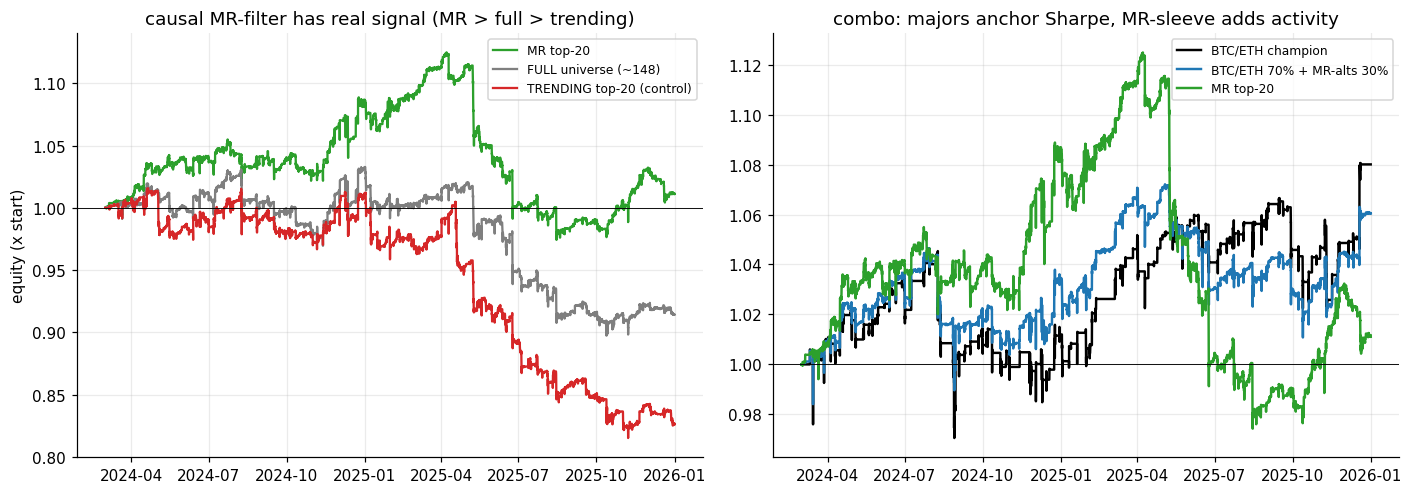

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
# panel A: the filter has signal
for name, c in [("MR top-20", "#2ca02c"), ("FULL universe (~148)", "#7f7f7f"), ("TRENDING top-20 (control)", "#d62728")]:
    ax1.plot(eqs[name].index, eqs[name], lw=1.5, color=c, label=name)
ax1.axhline(1, color="k", lw=0.6); ax1.legend(fontsize=8); ax1.set_ylabel("equity (x start)")
ax1.set_title("causal MR-filter has real signal (MR > full > trending)")
# panel B: the combo win — activity + lower DD at ~same Sharpe
for name, c in [("BTC/ETH champion", "#000000"), ("BTC/ETH 70% + MR-alts 30%", "#1f77b4"), ("MR top-20", "#2ca02c")]:
    ax2.plot(eqs[name].index, eqs[name], lw=1.6, color=c, label=name)
ax2.axhline(1, color="k", lw=0.6); ax2.legend(fontsize=8)
ax2.set_title("combo: majors anchor Sharpe, MR-sleeve adds activity")
show("06_curated_universe")

## Verdict — the causal MR-filter is real; standalone alts still lose; the *combo* is the graduation candidate

**(1) The filter has genuine, causal signal.** Selecting the most mean-reverting names by *trailing* 60-day autocorr (no lookahead), rebalanced monthly, orders cleanly:\n\n| config | return | Sharpe | maxDD | time-in-pos |\n|---|---|---|---|---|\n| MR top-20 | **+1.1%** | +0.12 | −13.4% | 38% |\n| FULL universe (~148) | −8.6% | −0.65 | −13.1% | 76% |\n| TRENDING top-20 (control) | **−17.4%** | −1.23 | −19.8% | 38% |\n\nMR **> full > trending**, monotone — so nb05's mechanism is *causally exploitable*, not a hindsight artifact. K=20 is the sweet spot (top-10 too concentrated −5.8%; top-30 dilutes −3.8%). A trailing **vol** screen did *not* help (MR∩low-vol −6.1%, lowest-vol −4.6%) — in this bear the low-vol alts are the dying/illiquid ones; autocorr is the better selector.\n\n**(2) But no alt basket beats the majors in this window.** Best alt basket +1.1% / Sharpe 0.12 vs BTC/ETH +8.0% / Sharpe 0.55. The 2024–26 alt bear drags even the most mean-reverting alts (MR top-20 ran to +12% by Apr-2025 then gave most of it back in the mid-2025 alt selloff). Curation fixes *which* alts, not the fact that alts as a class were a bad place to be.\n\n**(3) The real prize is the combo — BTC/ETH + a causal MR-alt sleeve:**\n\n| config | return | Sharpe | maxDD | time-in-pos |\n|---|---|---|---|---|\n| BTC/ETH champion | +8.0% | 0.55 | −7.3% | **8%** |\n| **BTC/ETH 70% + MR-alts 30%** | +6.1% | 0.51 | **−5.7%** | **40%** |\n\nThe sleeve trades a **hair of return/Sharpe** (8.0→6.1%, 0.55→0.51) for **5× the activity** (8%→40%) and a **lower drawdown** (−7.3→−5.7%, diversification). That trade is uninteresting on raw Sharpe — but it targets the champion's *actual* binding constraint: the composite penalizes time-in-position < 20% (up to a full 1.0 point), and the champion sits at 8%, deep in the penalty. Clearing that floor while *improving* drawdown and barely moving Sharpe could be a **net composite win** even though raw performance dips slightly.\n\n### Honest status\nThis is a **candidate to graduate, not a proven improvement.** My sim's Sharpe ≠ the harness OOS Sharpe, and the composite math (WF + DSR + activity + stitched) is exactly the thing that decides whether the activity/DD trade beats the Sharpe haircut. That adjudication belongs to the **harness**, not this sim. The clean, honest deliverable from this line: a **causal MR-selection rule** (trailing-autocorr top-K, monthly) that is validated to pick the right names, plus the specific hypothesis *\"BTC/ETH + 30% MR-alt sleeve raises composite via activity-penalty relief + lower DD.\"*\n\n**Recommended graduation step (user-run, separate from this notebook line):** port the combo into a `strategies/` variant — BTC/ETH plus a monthly trailing-autocorr top-K alt sleeve — and let `runner.iterate` judge the composite. Prediction: composite rises vs the 2-name champion despite the small Sharpe dip, driven by clearing the time-in-position penalty.\n\n**Caveats.** Notebook lens (not harness); equal-weight sleeve, no per-name risk budgeting; monthly rebalance, 60-day character window (both unswept); single alt-bear regime; combo weight (30%) picked by hand, not optimized (0.5 was slightly worse)."